# Development of single-step analysis

In [2]:
%reset -f
from importlib import reload
from pylib import agn_steps; reload(agn_steps)
from pylib.agn_steps import (VarDB, select_single_step, ratio_vs_time, set_theme, show_date, 
                             association_breakdown, pulsar_only, main,
                             show,np, pd, hist_bbvar)
set_theme(['dark']); show_date()

<h5 style="text-align:right; margin-right:15px"> 2026-03-17 08:48</h5>

* Loaded wtlike-generated variability info for 8677 sources from file `files/source_info_v3.pkl`

* Load uw1410 and 4FGL-DR4 info for the 8677 sources 

Loaded UW model uw1410: 11786 entries
Loaded Fermi 4FGL gll_psc_dr4.fit: 7195 entries


* a 7105 4FGL-DR4 point sources from `gll_psc_dr4.fit`

* Categorize according to the "class1" value:

,bll,fsrq,bcu,psr,other,unid
all,1469,799,1579,314,363,2178


### Detect the single-steppers
Here I select BB light curves with exactly two blocks, and record the ratio
of the two levels (the steps), and the position of the transition.
The light curves were generated with a bin width of 7 days, so the "step" position
must be at a bin boundary, the boundary position depending on the BB algorithm, its uncertainty TBD.
Ratios close to 1.0 are possibly an artifact of the BB procedure, this needs study.

Apply margin=100 weeks: <br>Found 494 candidates, with the association categories

,bll,fsrq,bcu,psr,other,unid
s-s cand.,140,17,134,17,23,163


<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0xf32b7b540ec0>
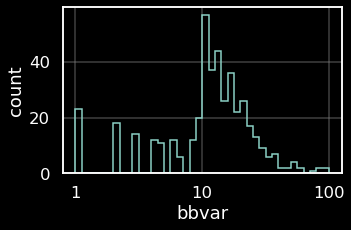

After applying the `bbvar>10' cut, we have 290 single-step candidates, with the following association breakdown:

,bll,fsrq,bcu,psr,other,unid
bbvar>10,93,12,79,14,14,78


In [3]:
margin, bbvar_min = 100,10
vdb = VarDB().load_cats().matchup()   
dfv = vdb.dfx
show(association_breakdown(dfv, name='all'))
df = select_single_step(vdb, margin)
show(hist_bbvar(df,))
dfss = df[df.bbvar>bbvar_min].copy()

show(f"""After applying the `bbvar>{bbvar_min}' cut, we have {len(dfss)} single-step candidates, with the following association breakdown:""")
show(association_breakdown(dfss, name=f'bbvar>{bbvar_min}'))

## Steps: ratio vs. time for blazars

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0xf32b7b0d3920>
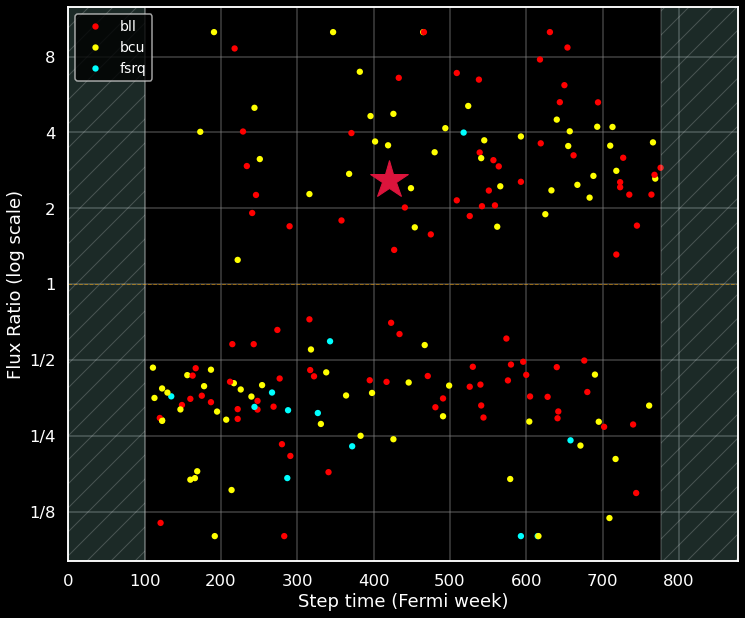

Notes:
* The star is the location, after correction for a nearby blazar, of PKS J2333-2343. 
          Because of that, it was not initially included.
* The fraction BL Lacs (6 %) is much larger than that for FSRQs (2 %)).
* There are fewer steps-up (80) than steps-down (104), and the up-steps concentrate, 
 at the end,
while the fewer down-steps are similarly concentrated at the start. 

In [10]:
reload(agn_steps); from pylib.agn_steps import ratio_display,ratio_vs_time, hist_bbvar
ratio_vs_time(dfss, dfv, margin, quiet=False)

In [5]:
dfv

,delta,ts,r95,glat,glon,eflux100,nbb,bbvar,class1,variability,pindex,curvature,e0,sin_b,uw_name,association,category
4FGL-DR4,,,,,,,,,,,,,,,,,
4FGL J0000.3-7355,0.017568,71.917691,0.047307,-42.735827,307.731328,9.873368e-13,1,0,,12.834996,2.083958,0.217188,2816.984867,-0.678619,J0000.1-7354,unid,unid
4FGL J0000.5+0743,0.069205,41.813026,0.142617,-52.968636,101.711343,1.059164e-12,1,0,,25.568989,1.000000,0.389761,1468.925888,-0.798306,J0000.5+0747,unid,unid
4FGL J0001.2+4741,0.018705,44.447195,0.050961,-14.332097,114.268500,1.296669e-12,5,77,bcu,28.915590,2.114247,0.059840,2958.943838,-0.247542,J0001.3+4741,bcu,bcu
4FGL J0001.2-0747,0.000796,702.004352,0.023192,-67.304941,89.030669,6.967148e-12,2,51,bll,51.742390,2.075954,0.030166,1989.839504,-0.922571,J0001.2-0747,bll,bll
4FGL J0001.4-0010,0.011551,36.645580,0.063038,-60.480714,96.901228,9.916332e-13,11,147,bll,9.374194,1.996587,0.080497,3623.290190,-0.870190,J0001.4-0009,bll,bll
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4FGL J2352.1-4301,0.058101,54.386399,0.113241,-70.121557,336.325743,1.546672e-12,2,10,bcu,19.192926,2.379369,0.068172,688.504735,-0.940416,J2352.1-4257,bcu,bcu
4FGL J2355.5-6614,0.038856,328.879721,0.059356,-49.969732,311.586619,3.180903e-12,3,41,,18.063284,2.371837,0.367091,818.127050,-0.765705,J2355.8-6612,unid,unid
4FGL J2358.3-1021,0.020999,835.538885,0.049998,-69.066533,83.721937,8.671854e-12,11,392,fsrq,226.776855,2.554469,0.093428,479.168130,-0.933996,J2358.3-1020,fsrq,fsrq
